## makemore: becoming a backprop ninja

These are my solutions along with my notes to the Backprop exercises.

https://www.youtube.com/watch?v=q8SA3rM6ckI&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&index=5

In [76]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [77]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [78]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [79]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [80]:
# ok biolerplate done, now we get to the action:

In [81]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [82]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

4137


In [83]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

In [84]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3510, grad_fn=<NegBackward0>)

In [85]:
print(logprobs.shape)
logprobs

torch.Size([32, 27])


tensor([[-2.6343, -2.4828, -3.9374, -3.0069, -3.9197, -2.5682, -3.7196, -3.3325,
         -4.0630, -3.4298, -3.2993, -3.3055, -3.2161, -3.4761, -3.2601, -4.2633,
         -4.6954, -3.9259, -4.1575, -2.9656, -2.8927, -3.8775, -3.6200, -2.6576,
         -2.8862, -3.7396, -3.7289],
        [-3.0015, -2.8757, -2.3072, -2.9491, -3.3411, -3.4581, -3.9843, -3.0251,
         -3.9603, -3.7539, -3.0236, -3.1501, -2.9913, -3.5308, -3.1352, -3.2618,
         -3.5936, -4.0738, -3.8122, -3.2401, -3.8153, -3.8185, -4.1700, -2.7589,
         -3.7933, -3.4553, -3.5069],
        [-3.9914, -3.7894, -4.2155, -4.3122, -3.7224, -3.2482, -2.8408, -2.7409,
         -2.8832, -3.4713, -3.8819, -3.4297, -3.0029, -2.9748, -3.7995, -3.6643,
         -4.2464, -3.4249, -3.4998, -2.2952, -2.6117, -3.3573, -3.1344, -3.1817,
         -3.2766, -4.0282, -3.5254],
        [-3.4560, -3.5985, -3.1105, -2.9579, -2.8261, -3.6447, -3.1229, -3.1658,
         -3.0653, -4.0039, -3.3334, -3.6778, -3.3282, -3.1586, -2.7742, -2.7807

Brief Notes for myself:

For the above, the loss is defined as the sum of the predicted log probabilties of the actual answer. $\newcommand{\d}{\partial} \newcommand{\dL}{\d L} \newcommand{\p}[2]{\frac{\d #1}{\d #2}} \newcommand{\pt}[2]{\frac{\d \text{#1}}{\d \text{#2}}} \newcommand{\pl}[1]{\p{L}{#1}} \newcommand{\plt}[1]{\p{L}{\text{#1}}}$

$\log \text{probs}:$

We know that $\p{L}{L} = 1$.

Since $L = -\frac{(a+b+c+\dots)}{n}$, where $a, \dots$ are the predicted probabilities for the actual answer, we can see that $\pl{a} = \pl{b} = \dots = -\frac{1}{n}$.

$\text{probs}:$

The probabilities from the log probabilities are defined as $\log(\mathrm{probs})$.

Hence we have that $\pl{\text{probs}} = \pl{\log \text{probs}} \cdot \p{\log \text{probs}}{\text{probs}} = \pl{\log \text{probs}} \cdot \frac{1}{\text{probs}}$

`counts_sum_inv`:

We have `probs = counts * counts_sum_inv`. Note that this is elementwise multiplication.

We note that `counts` has shape `[32, 27]` and `counts_sum_inv` has shape `[32, 1]`. This means `counts_sum_inv` will get repeated along dimension 1. As an example, for a `[2, 2]` and a `[2, 1]`, we have:
$$
\text{probs}=  \begin{bmatrix}
c_{11} & c_{12}\\
c_{21} & c_{22}
\end{bmatrix} = \text{counts} \circ \text{counts sum inv} = \begin{bmatrix}
a_{11} & a_{12}\\
a_{21} & a_{22}
\end{bmatrix} \circ
\begin{bmatrix}
b_{11} & b_{11}\\
b_{12} & b_{12}
\end{bmatrix} = \begin{bmatrix}
a_{11}b_{11} & a_{12}b_{11}\\
a_{21}b_{21} & a_{22}b_{22}
\end{bmatrix} =
$$

Noted that $\pl{b_{11}} = \pl{c_{11}} \cdot \p{c_{11}}{b_{11}} + \pl{c_{12}} \cdot \p{c_{12}}{b_{11}} = \pl{c_{11}} \cdot a_{11} + \pl{c_{12}} \cdot a_{12}$.

This is essentially $\pl{\text{counts sum inv}} = \pl{\text{probs}} \cdot \p{\text{probs}}{\text{counts sum inv}}$. This can be calculated with an elementwise multiplcation with $\pl{\text{probs}} \circ \text{counts}$ and a sum along the first dimension. (Like removing all the b elements in the above c matrix and summing row-wise.

`counts_sum`:

Since $\text{count sum inv} = \frac{1}{\text{counts sum}}$ we have $\pl{\text{counts sum}} = \pl{\text{counts sum inv}} \cdot \p{\text{counts sum inv}}{\text{counts sum}} = \pl{\text{counts sum inv}} \cdot -\frac{1}{\text{counts sum}^{\circ 2} }$

`counts`:

Noted that `counts` contributes to `counts_sum` and `probs`.
$$
\plt{counts} = \plt{counts sum} \pt{counts sum}{counts} + \plt{probs} \pt{probs}{counts}
$$

For $\pt{probs}{counts}$, we know that `probs = counts * counts_sum_inv`, so $\plt{probs} \pt{probs}{counts} =  \plt{probs}\circ \text{counts sum inv}$.

For $\pt{counts sum}{counts}$, we know that `counts_sum = counts.sum(1, keepdims=True)`. This means for each element in `counts`, it will contribute its sum to one cell. Hence we get that $\plt{counts sum} \pt{counts sum}{counts} = \plt{counts sum}$.

We can sum the results to get our answer.

`norm_logits`:

We note that `counts = norm_logits.exp()`. This is elementwise exponential and the it's a simple derivative of:
$$
\plt{norm logits} = \plt{counts} \cdot \pt{counts}{norm logits} = \plt{counts} \cdot e^{\text{norm logits}} = \plt{counts} \circ \text{counts}
$$

`logit_maxes`:

We note that `norm_logits = logits - logit_maxes`.

The shape of `norm_logits` is `[32, 27]` and the shape of `logits_maxes` is `[32, 1]`, so `logits_maxes` will get broadcasted.

This is a simple -1 derivative (but we sum along the first dimension to collect all the contribution from `logits_maxes` subtract among the first dimension due to broadcasting).
$$
\plt{logit maxes} = \plt{logits} \cdot \pt{logits}{logit maxes} = -\plt{logits}
$$

`logits`:

We have two contributions of `logits`: `norm_logits = logits - logit_maxes` and `logit_maxes = logits.max(1, keepdim=True).values`.

This means we have

For `norm_logits = logits - logit_maxes`, we effectively have $ \plt{logits} = \plt{norm logits}$.

For `logit_maxes = logits.max(1, keepdim=True).values`, we can only give contribution to the maximum value along dimension 1. This means that for each set of values along dimension 1, the maximum is chosen and contributes to the gradient of `logits_maxes`.
Luckily since each value only contributes 1, we just need to copy the gradient to the maximum indices.

It is noted that `logit_maxes` shouldn't contribute anything as it is subtracting the maximum for numerical stability. In theory, setting the value of `logit_maxes` should result in the same value, so `logit_maxes` should have a zero gradient.

`h`:

We have `logits = h @ W2 + b2`. This is a matrix multiplication instead of a elementwise multiplication.

It is noted for a single element in `h`, it contributes to all the elements of the same column in the resulting matrix. It also is multiplied by elements in the same corresponding column in `W2`. By derivative of a matrix multiplication, we would need to dot multiply the derivative of the resulting column by the column in `W2`. This can be done by transposing `W2` and matrix multiplying the matrices, giving us `dh =  dlogits @ W2.T`.

`W2`: Similarly, like `h`, we have `dW2 = h.T @ dlogits`.

Noted that we multiply differently due to the order of the matrix multiplication.

`b2`:

`b2` has a shape of `[27]` and `dlogits` has a shape of `[32, 27]` Hence `b2` will get broadcasted among dimension 0. Since it's a simple sum (derivative 1 times `dlogits`), we can just sum along dimension 0 of `dlogits` to get the contribution of `b2`.

`hpreact`:

`h = torch.tanh(hpreact)`

The derivative of $\tanh(x)$ is $1-\tanh(x)^2$, so we can simply just multiply $1-h^2$ with `dh`.

`bngain`:

We have `hpreact = bngain * bnraw + bnbias`.

Noted that `hpreact` and `bnraw` have dimensions of `[32, 64]` while `bngain` has a dimension of `[1, 64]`, meaning `bngain` is broadcasted among dimension 0. For each element in `bngain`, it gets element-wise multiplied by each column in `bnraw`. With element-wise, we can just compute the resulting derivative matrix and sum along the columns to get the total contribution.

`bnbias`: Similarly, we can just sum along the column for `hpreact`.

`bnraw`: Luckily we don't need to do any broadcasting sum shenanigans.

`bnvar_inv`:

We have `bnraw = bndiff * bnvar_inv`.
dbnraw:  torch.Size([32, 64])
bndiff:  torch.Size([32, 64])
bnvar_inv torch.Size([1, 64])

Hence we need to sum along dimension 0.

`bnvar`:

`bnvar_inv = (bnvar + 1e-5)**-0.5`.

With derivatives we can get that:
$$
\plt{bnvar} = \plt{bnvar inv} \cdot \pt{bnvar inv}{bnvar} =  \plt{bnavar inv} \cdot (-0.5) \cdot (\text{bnvar} + 10^{-5})^{-1.5}
$$

`bndiff2`:

`bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True)`

We apply the derivatives the same among dimension 0 (however note since it's just a sum and they each only contribute 1 so nothing needs to be done to `bndiff2`) and multiply by $\frac{1}{n-1}$.

`bndiff`:

There are two contributions: `bndiff2 = bndiff**2` and `bnraw = bndiff * bnvar_inv`.

For `bnraw = bndiff * bnvar_inv` we do the same as `bnvar_inv` (this time broadcasting will avoid sum shenanigans).

For `bndiff2 = bndiff**2`, the derivative is `2 * bndiff`.

Hence we have
$$
\begin{align*}
\plt{bndiff} &= \plt{bndiff2} \cdot \pt{bndiff2}{bndiff} + \plt{bnraw} \cdot \pt{bnraw}{bndiff}\\
&= \plt{bndiff2} \cdot 2 \cdot \text{bndiff} + \plt{bnraw} \cdot \text{bnvar inv}
\end{align*}
$$

`bnmeani`:

bndiff = hprebn - bnmeani

Hence its just `-bndiff` (with sum along first dimension due to broadcasting).

`hprebn`:

This has two contributions:
1. `bnmeani = 1/n*hprebn.sum(0, keepdim=True)`
2. `bndiff = hprebn - bnmeani`

The second contribution is easy, the first contirbution is a `1/n * dbnmeani` (this is kinda getting repetitive).

`embcat`:

`hprebn = embcat @ W1 + b1`

Same as above lol.

`W1`: `hprebn = embcat @ W1 + b1`, same as above.

`b1`: Same as above we just need to deal with the broadcasting of `b1` by applying a sum on dim 0 along `dhprebn`.

`emb`:

`embcat = emb.view(emb.shape[0], -1)` We just need to copy the gradient from `embcat` and shape it to emb.

`C`:

`emb = C[Xb]`. We can use Xb to copy the gradients of `emb` into `C`.

We note that `Xb` is a `[32, 3]` array, `C` is a `[27, 10]` array, meaning `emb` is a `[32, 3, 10]` array.

Hence `emb` is a bunch of `C[some index in Xb]` arrays concatenated together.

Hence, we should loop over every value in `Xb`, and find the index that corresponds to which `C` array we should contribute to, and then add the contribution.

In [86]:
# Exercise 1: backprop through the whole thing manually,
# backpropagating through exactly all of the variables
# as they are defined in the forward pass above, one by one

from torch import Tensor

# -----------------
# YOUR CODE HERE :)
# -----------------

dlogprobs = torch.zeros(logprobs.shape)
for i, y in enumerate(Yb):
    dlogprobs[i, y] -= 1/n

dprobs = dlogprobs /probs

# print(dprobs.shape)

dcounts_sum_inv = (dprobs * counts).sum(1, keepdim= True)

# print(counts.T.shape)

# print("probs: ", probs.shape)
# print("counts: ", counts.shape)
# print("counts_sum_inv: ", counts_sum_inv.shape)
# print(dcounts_sum_inv.shape)

dcounts_sum = dcounts_sum_inv * (-1/(counts_sum*counts_sum))

dcounts = dprobs * counts_sum_inv + dcounts_sum

dnorm_logits = dcounts * counts

dlogit_maxes = (-dnorm_logits.sum(1, keepdim=True))

# print("norm_logits:", norm_logits.shape)
# print("logit_maxes", logit_maxes.shape)
# print("dlogits_maxes", dlogit_maxes.shape)

dlogits = (dlogit_maxes * (logits == logits.max(1, keepdim=True).values).float())
dlogits += dnorm_logits

# print((logits == logits.max|1, keepdim=True)[0]))
# print("dlogits", dlogits.shape)
# print(logit_max_indices.shape)
# print("dlogits_maxes", dlogit_maxes.shape)
# print("logits", logits.shape)

dh = dlogits @ W2.T

dW2 = h.T @ dlogits

db2 = dlogits.sum(0)
# print(b2.shape)
# print(db2.shape)
# print(dlogits.shape)

dhpreact = dh * (1-h**2)

dbngain = (dhpreact * bnraw).sum(0)
# print("bnraw: ", bnraw.shape)
# print("dhpreact: ", dhpreact.shape)
# print("hpreact: ", hpreact.shape)
# print("bngain: ", bngain.shape)
# print("dbngain: ", dbngain.shape)

dbnbias = dhpreact.sum(0)

dbnraw = dhpreact * bngain

dbnvar_inv = (dbnraw * bndiff).sum(0)
# print("dbnraw: ", dbnraw.shape)
# print("bndiff: ", bndiff.shape)
# print("bnvar_inv", bnvar_inv.shape)

dbnvar = dbnvar_inv * -0.5 * (bnvar + 1e-5)**-1.5

dbndiff2 = 1/(n-1) * dbnvar

dbndiff = bnvar_inv * dbnraw + 2 * bndiff * dbndiff2

dbnmeani = -dbndiff.sum(0)

dhprebn = dbndiff + 1/n * dbnmeani

dembcat =  dhprebn @ W1.T

dW1 = embcat.T @ dhprebn

db1 = dhprebn.sum(0)

demb = dembcat.view(emb.shape)

# print("C: ", C.shape)
# print("emb: ", emb.shape)
# print("Xb: ", Xb.shape)

dC = torch.zeros(C.shape)
for i in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[i, j]
        dC[ix] += demb[i, j]

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

### Bessel's Correction:

A correct that multiplies by $\frac{1}{n-1}$ instead of $\frac{1}{n}$ to give a better estimate of the variance when the samples sizes are small compared to the population/dataset size.

Pytorch batchnorm does not let you choose the unbiased/biased version of variance.

Improved Code with ideas from video and elsewhere:

In [94]:
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n
dprobs = dlogprobs/probs

dcounts_sum_inv = (dprobs * counts).sum(1, keepdim= True)

dcounts_sum = -dcounts_sum_inv*(counts_sum**-2) # no division to keep it exact like pytorch

dcounts = dprobs * counts_sum_inv + dcounts_sum

dnorm_logits = dcounts * counts

dlogit_maxes = (-dnorm_logits.sum(1, keepdim=True))

# dlogits = (dlogit_maxes * (logits == logits.max(1, keepdim=True).values).float())
# dlogits += dnorm_logits
# Video:
dlogits = dnorm_logits.clone()
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes

dh = dlogits @ W2.T

dW2 = h.T @ dlogits

db2 = dlogits.sum(0)

dhpreact = dh * (1-h**2)

dbngain = (dhpreact * bnraw).sum(0)

dbnbias = dhpreact.sum(0)

dbnraw = dhpreact * bngain

dbnvar_inv = (dbnraw * bndiff).sum(0)

dbnvar = dbnvar_inv * -0.5 * (bnvar + 1e-5)**-1.5

dbndiff2 = 1/(n-1) * dbnvar # changing this to division makes it not exact

dbndiff = bnvar_inv * dbnraw + 2 * bndiff * dbndiff2

dbnmeani = -dbndiff.sum(0)

dhprebn = dbndiff + dbnmeani/n

dembcat =  dhprebn @ W1.T

dW1 = embcat.T @ dhprebn

db1 = dhprebn.sum(0)

demb = dembcat.view(emb.shape)

dC = torch.zeros(C.shape)
for i in range(Xb.shape[0]):
  for j in range(Xb.shape[1]):
    ix = Xb[i, j]
    dC[ix] += demb[i, j]

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

In [45]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.3354313373565674 diff: 2.384185791015625e-07


Let's look at the mathematical expression of the loss.

Suppose we have a $2\times 3$ matrix.
$$
\begin{bmatrix}
a_{11} & a_{12} & a_{13} \\
a_{21} & a_{22} & a_{23}
\end{bmatrix}
$$

After the probs step, we get

$$
\begin{bmatrix}
\frac{e^{a_{11} - m_1}}{e^{a_{11} - m_1} + e^{a_{12} - m_1} + e^{a_{13} - m_1}} &
\frac{e^{a_{12} - m_1}}{e^{a_{11} - m_1} + e^{a_{12} - m_1} + e^{a_{13} - m_1}} &
\frac{e^{a_{13} - m_1}}{e^{a_{11} - m_1} + e^{a_{12} - m_1} + e^{a_{13} - m_1}} \\
\frac{e^{a_{21} - m_2}}{e^{a_{21} - m_2} + e^{a_{22} - m_2} + e^{a_{23} - m_2}} &
\frac{e^{a_{22} - m_2}}{e^{a_{21} - m_2} + e^{a_{22} - m_2} + e^{a_{23} - m_2}} &
\frac{e^{a_{23} - m_2}}{e^{a_{21} - m_2} + e^{a_{22} - m_2} + e^{a_{23} - m_2}}
\end{bmatrix}
$$
with $m_1 = \max(a_{11}, a_{12}, a_{13}), m_2 = \max(a_{21}, a_{22}, a_{23})$. Note that we can multiply by $e^{m_1}$ or $e_{m_2}$ to simplify these fractions, giving us:
$$
\begin{bmatrix}
\frac{e^{a_{11} }}{e^{a_{11} } + e^{a_{12} } + e^{a_{13} }} &
\frac{e^{a_{12} }}{e^{a_{11} } + e^{a_{12} } + e^{a_{13} }} &
\frac{e^{a_{13} }}{e^{a_{11} } + e^{a_{12} } + e^{a_{13} }} \\
\frac{e^{a_{21} }}{e^{a_{21} } + e^{a_{22} } + e^{a_{23} }} &
\frac{e^{a_{22} }}{e^{a_{21} } + e^{a_{22} } + e^{a_{23} }} &
\frac{e^{a_{23} }}{e^{a_{21} } + e^{a_{22} } + e^{a_{23} }}
\end{bmatrix}
$$

Then we take the $-\log()$ mean of one of the values in each row if to calculate the probabiltiies of the logits in `Yb`. This gives us
$$
\frac{1}{2}\left(-\log\left(\frac{e^{a_{11} }}{e^{a_{11} } + e^{a_{12} } + e^{a_{13} }}\right) + -\log\left(\frac{e^{a_{23} }}{e^{a_{21} } + e^{a_{22} } + e^{a_{23} }}\right)\right)
$$

We note that the derivative of $\log\left(\frac{e^{a_{11} }}{e^{a_{11} } + e^{a_{12} } + e^{a_{13} }}\right)$ with respect to $a_{11}$ is
$$
\frac{e^{a_{12}} + e^{a_{13}}}{e^{a_{11}}+e^{a_{12}}+e^{a_{13}}} = 1- \frac{e^{a_{11}}}{e^{a_{11}}+e^{a_{12}}+e^{a_{13}}}
$$
and the derivative of the log with respect to $a_{12}$ is
$$
\frac{e^{a_{12}}}{e^{a_{11}}+e^{a_{12}}+e^{a_{13}}}
$$
The exponential fraction terms can be calculated with a softmax along the first dimension. Then we add 1 to the correct logits and multiply by $-\frac{1}{n}$ to complete the derivative.

In [46]:
torch.tensor([[1, 2], [3, 4]]).max(1)

torch.return_types.max(
values=tensor([2, 4]),
indices=tensor([1, 1]))

In [47]:
# backward pass

# -----------------
# YOUR CODE HERE :)
dlogits = -F.softmax(logits, 1)
dlogits[range(n), Yb] += 1
dlogits *= -1/dlogits.shape[0]

# dlogits = None # TODO. my solution is 3 lines
# -----------------

cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

logits          | exact: False | approximate: True  | maxdiff: 6.05359673500061e-09


In [48]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out
# BatchNorm paper: https://arxiv.org/abs/1502.03167

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
#   = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


We are given the following formulas:

$$
\mu = \frac{1}{m} \sum x_i
$$

$$
\sigma^2 = \frac{1}{m-1} \sum(x_i-\mu)^2
$$

$$
\hat{x_i} = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}
$$

$$
y_i = \gamma \hat{x_i} + \beta
$$

We have that $\pl{y_i}$ and we want to find $\pl{x_i}$.

We know that $$
\begin{align*}
\pl{\hat{x_i}} &= \pl{y_i} \cdot \p{y_i}{\hat{x_i}}\\
&= \pl{y_i} \cdot \gamma
\end{align*}
$$

$$
\begin{align*}
\pl{\sigma^2} &= \sum_i \pl{\hat{x_i}} \cdot \p{\hat{x_i}}{\sigma^2} \\
&= \frac{1}{2}\cdot\gamma \sum_i \pl{y_i} \cdot (x_i-\mu)(\sigma^2 + \epsilon)^{-\frac{3}{2}}
\end{align*}
$$

$$
\begin{align*}
\pl{\mu} &= \pl{\sigma^2} \cdot \p{\sigma^2}{\mu} + \sum_i \pl{\hat{x_i}} \cdot \p{\hat{x_i}}{\mu}
\end{align*}
$$

Noted that
$$
\begin{align*}
\p{\sigma^2}{\mu} &= \frac{1}{m-1} \cdot \sum_i -2\left(x_i - \mu\right)\\
&= -\frac{2}{m-1} \cdot \sum_i x_i - \mu \\
&= -\frac{2}{m-1} \cdot \left(\sum_i x_i - \sum_i \mu\right)\\
&= 0
\end{align*}
$$
as $\sum_i \mu$ is the same as the sum of the elements $x_i$.

Hence we have that
$$
\begin{align*}
\pl{\mu} &= \pl{\sigma^2} \cdot \p{\sigma^2}{\mu} + \sum_i \pl{\hat{x_i}} \cdot \p{\hat{x_i}}{\mu}\\
&= \sum_i \pl{\hat{x_i}} \cdot \p{\hat{x_i}}{\mu} \\
&= \sum_i \left( \pl{y_i} \cdot \gamma\right) \cdot -(\sigma^2+\epsilon)^{-\frac{1}{2}}
\end{align*}
$$

$$
\begin{align*}
\pl{x_i} &= \pl{\hat{x_i}} \cdot \p{\hat{x_i}}{x_i} + \pl{\mu} \cdot \p{\mu}{x_i} + \pl{\sigma^2} \cdot \p{\sigma^2}{x_i}\\
\end{align*}
$$

We have
$$
\begin{align*}
\p{\hat{x_i}}{x_i} &= (\sigma^2 + \epsilon)^{-\frac{1}{2}} \\
\end{align*}
$$

$$
\begin{align*}
\p{\mu}{x_i} &= \frac{1}{m}
\end{align*}
$$

$$
\begin{align*}
\p{\sigma^2}{x_i} &= \frac{2}{m-1}(x_i - \mu)
\end{align*}
$$

$$
\begin{align*}
\pl{\sigma^2} \cdot \p{\sigma^2}{x_i} &= \left( \frac{1}{2}\cdot\gamma \sum_j \pl{y_j} \cdot (x_j-\mu)(\sigma^2 + \epsilon)^{-\frac{3}{2}}\right) \cdot \left(\frac{2}{m-1}(x_i - \mu)\right)\\
&=\left(\gamma \sum_j \pl{y_j} \cdot (x_j-\mu)(\sigma^2 + \epsilon)^{-\frac{3}{2}}\right) \cdot \left(\frac{1}{m-1}(x_i - \mu)\right)\\
&=\gamma(\sigma^2 + \epsilon)^{-\frac{1}{2}}\cdot \left( \sum_j \pl{y_j} \cdot (x_j-\mu)(\sigma^2 + \epsilon)^{-\frac{1}{2}}\right) \cdot \left(\frac{1}{m-1}(x_i - \mu) \cdot (\sigma^2 + \epsilon)^{-\frac{1}{2}} \right)\\
\end{align*}
$$

Noted that $\hat{x_i} = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}}$

$$
\begin{align*}
&=\gamma(\sigma^2 + \epsilon)^{-\frac{1}{2}}\cdot \left(\sum_j \pl{y_j} \cdot \hat{x_j} \right) \cdot \left(\frac{1}{m-1}\hat{x_i} \right)\\
\end{align*}
$$

so we have
$$
\begin{align*}
\pl{x_i} &= \pl{\hat{x_i}} \cdot \p{\hat{x_i}}{x_i} + \pl{\mu} \cdot \p{\mu}{x_i} + \pl{\sigma^2} \cdot \p{\sigma^2}{x_i}\\
&= \left(\pl{y_i} \cdot \gamma\right)\left((\sigma^2 + \epsilon)^{-\frac{1}{2}}\right) + \left(\sum_j \left( \pl{y_j} \cdot \gamma\right) \cdot -(\sigma^2+\epsilon)^{-\frac{1}{2}}\right)\left(\frac{1}{m}\right) + \gamma(\sigma^2 + \epsilon)^{-\frac{1}{2}}\cdot \left(\sum_j \pl{y_j} \cdot \hat{x_j} \right) \cdot \left(\frac{1}{m-1}\hat{x_i} \right)\\
&= \gamma(\sigma^2 + \epsilon)^{-\frac{1}{2}} \left(\pl{y_i} +\frac{1}{m} + \sum_j \left( \pl{y_j}\right) +\frac{1}{m-1}\hat{x_i}\cdot \left(\sum_j \pl{y_j} \cdot \hat{x_j} \right)  \right)
\end{align*}
$$

In [49]:
# backward pass
# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

# -----------------
# YOUR CODE HERE :)


# dhprebn = bnvar_inv * bngain * dhpreact + (2*bndiff) * ((1.0/(n-1))*torch.ones_like(bndiff2) * (-0.5*(bnvar + 1e-5)**-1.5) * (bndiff * bngain * dhpreact).sum(0, keepdim=True)) + 1.0/n * (torch.ones_like(hprebn) * ((-(bnvar_inv * bngain * dhpreact + (2*bndiff) * ((1.0/(n-1))*torch.ones_like(bndiff2) * (-0.5*(bnvar + 1e-5)**-1.5) * (bndiff * bngain * dhpreact).sum(0, keepdim=True)))).sum(0)))

dhprebn = bngain * bnvar_inv * (dhpreact - 1/n * dhpreact.sum(0) - 1/(n-1) * bnraw * (dhpreact * bnraw).sum(0))

# dhprebn = bngain * dhpreact # TODO. my solution is 1 (long) line
# -----------------

cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 4.656612873077393e-10


`dlogits`:

In each row, we pull up the probability of the right characters and pull down the probabilities of the wrong characters.

In [96]:
dlogits[0].sum()

tensor(4.6566e-10, grad_fn=<SumBackward0>)

This is close to $0$, showing we pull down and pull up the probabilties by the same amount (the sum of probabilities has to be 1)

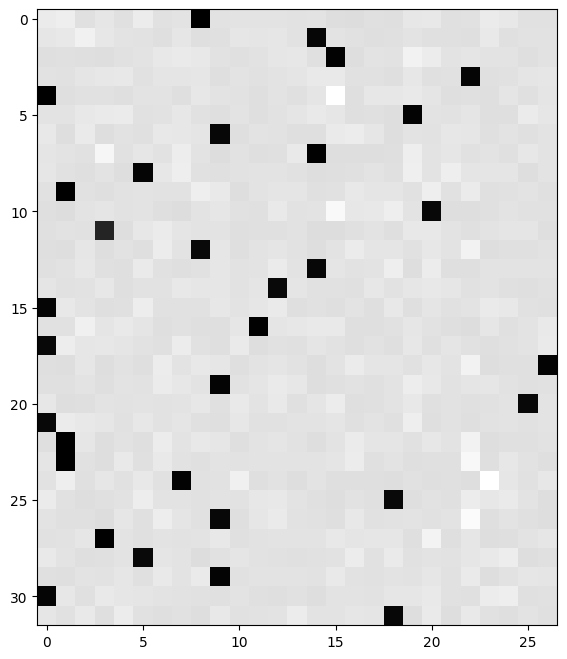

In [95]:
plt.figure(figsize=(8,8))
plt.imshow(dlogits.detach(), cmap='gray')

In [72]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
with torch.no_grad():
# kick off optimization
  for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hprebn = embcat @ W1 + b1 # hidden layer pre-activation
    # BatchNorm layer
    # -------------------------------------------------------------
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias
    # -------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    # for p in parameters:
    #   p.grad = None
    # loss.backward() # use this for correctness comparisons, delete it later!

    # manual backprop! #swole_doge_meme
    # -----------------
    # YOUR CODE HERE :)
    # dC, dW1, db1, dW2, db2, dbngain, dbnbias = None, None, None, None, None, None, None


    dlogits = -F.softmax(logits, 1)
    dlogits[range(n), Yb] += 1
    dlogits *= -1/n

    # 2nd layer
    dh = dlogits @ W2.T

    dW2 = h.T @ dlogits

    db2 = dlogits.sum(0)
    # tanh layer
    dhpreact = dh * (1-h**2)

    # batchnorm
    dbngain = (dhpreact * bnraw).sum(0)
    dbnbias = dhpreact.sum(0)

    dhprebn = bngain * bnvar_inv * (dhpreact - 1/n * dhpreact.sum(0) - 1/(n-1) * bnraw * (dhpreact * bnraw).sum(0))
    # noted i should do /n instead of 1/n * for higher precision

    # 1st layer

    dembcat =  dhprebn @ W1.T

    dW1 = embcat.T @ dhprebn

    db1 = dhprebn.sum(0)
    # embedding
    demb = dembcat.view(emb.shape)
    dC = torch.zeros(C.shape)
    for k in range(Xb.shape[0]):
      for j in range(Xb.shape[1]):
        ix = Xb[k, j]
        dC[ix] += demb[k, j]

    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    # -----------------

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p, grad in zip(parameters, grads):
      # p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
      p.data += -lr * grad # new way of swole doge TODO: enable

    # track stats
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    #
    # if i >= 100: # TODO: delete early breaking when you're ready to train the full net
    #   break

12297
      0/ 200000: 3.8160
  10000/ 200000: 2.1532
  20000/ 200000: 2.4057
  30000/ 200000: 2.4634
  40000/ 200000: 2.0354
  50000/ 200000: 2.3829
  60000/ 200000: 2.3920
  70000/ 200000: 1.9689
  80000/ 200000: 2.4473
  90000/ 200000: 2.0804
 100000/ 200000: 1.9725
 110000/ 200000: 2.2786
 120000/ 200000: 1.9389
 130000/ 200000: 2.4270
 140000/ 200000: 2.1925
 150000/ 200000: 2.1363
 160000/ 200000: 2.0167
 170000/ 200000: 1.8425
 180000/ 200000: 1.9867
 190000/ 200000: 2.0013


In [71]:
# useful for checking your gradients
for p,g in zip(parameters, grads):
  cmp(str(tuple(p.shape)), g, p)

(27, 10)        | exact: False | approximate: True  | maxdiff: 1.210719347000122e-08
(30, 200)       | exact: False | approximate: True  | maxdiff: 7.450580596923828e-09
(200,)          | exact: False | approximate: True  | maxdiff: 5.122274160385132e-09
(200, 27)       | exact: False | approximate: True  | maxdiff: 1.1175870895385742e-08
(27,)           | exact: False | approximate: True  | maxdiff: 3.725290298461914e-09
(1, 200)        | exact: False | approximate: True  | maxdiff: 2.3283064365386963e-09
(1, 200)        | exact: False | approximate: True  | maxdiff: 4.6566128730773926e-09


In [73]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)


In [74]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0720255374908447
val 2.1103200912475586


In [ ]:
# I achieved:
# train 2.0718822479248047
# val 2.1162495613098145

In [75]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass
      emb = C[torch.tensor([context])] # (1,block_size,d)
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

mora.
mayah.
see.
mad.
ryla.
reisha.
endraegusteredielin.
shi.
jen.
eden.
sana.
arleigh.
malaia.
noshubergahiriel.
kin.
renly.
panthona.
ube.
geda.
jamyleyeks.
